In [1]:
import gymnasium as gym
import tensorflow as tf
import numpy as np
import cv2
from collections import deque
from datetime import datetime
from pathlib import Path
import keras
from tensorflow.summary import create_file_writer
import os
import matplotlib.pyplot as plt

def pid(error, prev_error):
    Kp, Ki, Kd = 0.02, 0.03, 0.2
    return Kp * error + Ki * (error + prev_error) + Kd * (error - prev_error)

def preprocess_frame(frame):
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, (36, 25, 25), (70, 255, 255))
    green = np.zeros_like(frame)
    green[mask > 0] = frame[mask > 0]
    gray = cv2.cvtColor(green, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    canny = cv2.Canny(blur, 50, 150)
    cropped = canny[200:205, 200:400]
    return cropped

def find_error(crop, prev_error):
    nz = cv2.findNonZero(crop)
    mid = 100
    if nz is None:
        return prev_error
    if nz[:, 0, 0].max() == nz[:, 0, 0].min():
        return -15 if nz[:, 0, 0].max() >= mid else 15
    return ((nz[:, 0, 0].max() + nz[:, 0, 0].min()) / 2) - mid

def build_model():
    image_input = tf.keras.Input(shape=(5, 200, 1), name="canny_crop")

    # Smaller Conv stack
    x1 = tf.keras.layers.Conv2D(16, (3, 3), padding="same", activation="relu")(image_input)
    x1 = tf.keras.layers.MaxPooling2D()(x1)
    x1 = tf.keras.layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x1)
    x1 = tf.keras.layers.MaxPooling2D()(x1)
    x1 = tf.keras.layers.Flatten()(x1)

    # Simpler error processing
    error_input = tf.keras.Input(shape=(1,), name="error")
    x2 = tf.keras.layers.Dense(8, activation="relu")(error_input)

    # Fuse and output Q-values for 3 gas levels
    concat = tf.keras.layers.Concatenate()([x1, x2])
    x = tf.keras.layers.Dense(32, activation="relu")(concat)
    output = tf.keras.layers.Dense(3, activation=None)(x)

    model = tf.keras.models.Model(inputs=[image_input, error_input], outputs=output)
    model.compile(optimizer="adam", loss="mse")
    return model


def preprocess_inputs(crop, error):
    crop = crop.astype(np.float32) / 255.0
    crop = crop.reshape(1, 5, 200, 1)
    return [crop, np.array([[error / 100]], dtype=np.float32)]

def train_step(ep):
    batch_size = min(64, len(replay_buffer) // 10)
    batch = [replay_buffer[np.random.randint(len(replay_buffer))] for _ in range(batch_size)]
    crops, errors, action_idxs = zip(*batch)
    X_img = np.array(crops).reshape(batch_size, 5, 200, 1)
    X_err = np.array(errors).reshape(batch_size, 1)
    action_idxs = np.array(action_idxs, dtype=np.int32)

    q_values = model.predict([X_img, X_err], verbose=0)
    q_values_next = target_model.predict([X_img, X_err], verbose=0)
    targets = q_values.copy()

    for i in range(batch_size):
        action = action_idxs[i]
        targets[i, action] = q_values_next[i, action]

    loss = model.train_on_batch([X_img, X_err], targets)
    losses.append(loss)
    with writer.as_default():
        tf.summary.scalar("Loss/train", loss, step=ep)

In [2]:
model = build_model()
target_model = tf.keras.models.clone_model(model)
target_model.set_weights(model.get_weights())

log_dir = "logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")
writer = create_file_writer(log_dir)

replay_buffer = deque(maxlen=20000)
env = gym.make("CarRacing-v3", render_mode="rgb_array", lap_complete_percent=0.95, domain_randomize=False, continuous=True)
np.random.seed(42)
tf.random.set_seed(42)
env.reset(seed=42)

episodes = 500
rewards = []
best_score = -1000
gas_levels = [0.0, 0.5, 1.0]
losses = []

In [ ]:
for ep in range(episodes):
    obs, _ = env.reset()
    total_reward = 0
    prev_error = 0
    smoothed_reward = 0

    for step in range(1000):
        frame = env.render()
        crop = preprocess_frame(frame)
        error = find_error(crop, prev_error)

        steering = pid(error, prev_error)
        q_values = model.predict(preprocess_inputs(crop, error), verbose=0)[0]
        action_index = np.argmax(q_values)

        # just gas
        gas = gas_levels[action_index]
        action = np.array([steering, gas, 0], dtype=np.float32)

        # gas and break
        # pick = action_lst[action_index]
        # action = np.array([*pick, 0], dtype=np.float32)

        obs, reward, terminated, truncated, _ = env.step(action)
        smoothed_reward = 0.9 * smoothed_reward + 0.1 * float(reward)
        total_reward += smoothed_reward
        replay_buffer.append((crop, error, action_index))
        prev_error = error

        if len(replay_buffer) > 1000 and step % 4 == 0:
            train_step(ep)
            tau = 0.005
            for var, target_var in zip(model.trainable_variables, target_model.trainable_variables):
                target_var.assign(tau * var + (1 - tau) * target_var)
            with writer.as_default():
                for layer in model.layers:
                    weights = layer.get_weights()
                    if weights:
                        tf.summary.histogram(f"{layer.name}/weights", weights[0], step=ep)

        if terminated or truncated:
            break


    print(f"Episode {ep+1} - Reward: {total_reward:.2f}")
    rewards.append(total_reward)
    with writer.as_default():
        tf.summary.scalar("Reward/Episode", total_reward, step=ep)

    if total_reward > best_score and total_reward > 100:
        best_score = total_reward
        print(f" - New best score: {best_score:.2f}")
        if best_score > 100:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M")
            Path("models").mkdir(parents=True, exist_ok=True)
            file_path = os.path.join("models", f"{timestamp}_discrete_dqn.h5")
            keras.saving.save_model(model, file_path)

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
Path("models").mkdir(parents=True, exist_ok=True)
file_path = os.path.join("models", f"{timestamp}_discrete_dqn.h5")
keras.saving.save_model(model, file_path)

env.close()
writer.close()

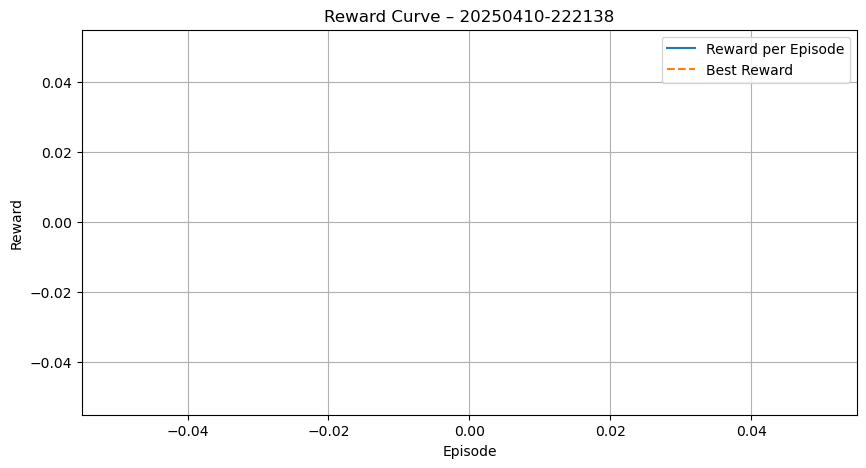

Saved plots to: images/20250410-222138_reward_plot_20250410_2224.png


In [ ]:
# ========== Plot and Save Curves ==========
Path("images").mkdir(exist_ok=True)
model_name = Path(log_dir).name
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# Reward Plot
plt.figure(figsize=(10, 5))
plt.plot(rewards, label="Reward per Episode")
plt.plot([max(rewards[:i+1]) for i in range(len(rewards))], linestyle='--', label="Best Reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title(f"Reward Curve – {model_name}")
plt.grid(True)
plt.legend()
reward_path = f"images/{model_name}_reward_plot_{timestamp}.png"
plt.savefig(reward_path)
plt.show()

# Loss Plot
if losses:
    plt.figure(figsize=(10, 5))
    plt.plot(losses, label="Loss per Train Step")
    plt.xlabel("Train Step")
    plt.ylabel("Loss")
    plt.title(f"Loss Curve – {model_name}")
    plt.grid(True)
    plt.legend()
    loss_path = f"images/{model_name}_loss_plot_{timestamp}.png"
    plt.savefig(loss_path)
    plt.show()

print(f"Saved plots to: {reward_path}")

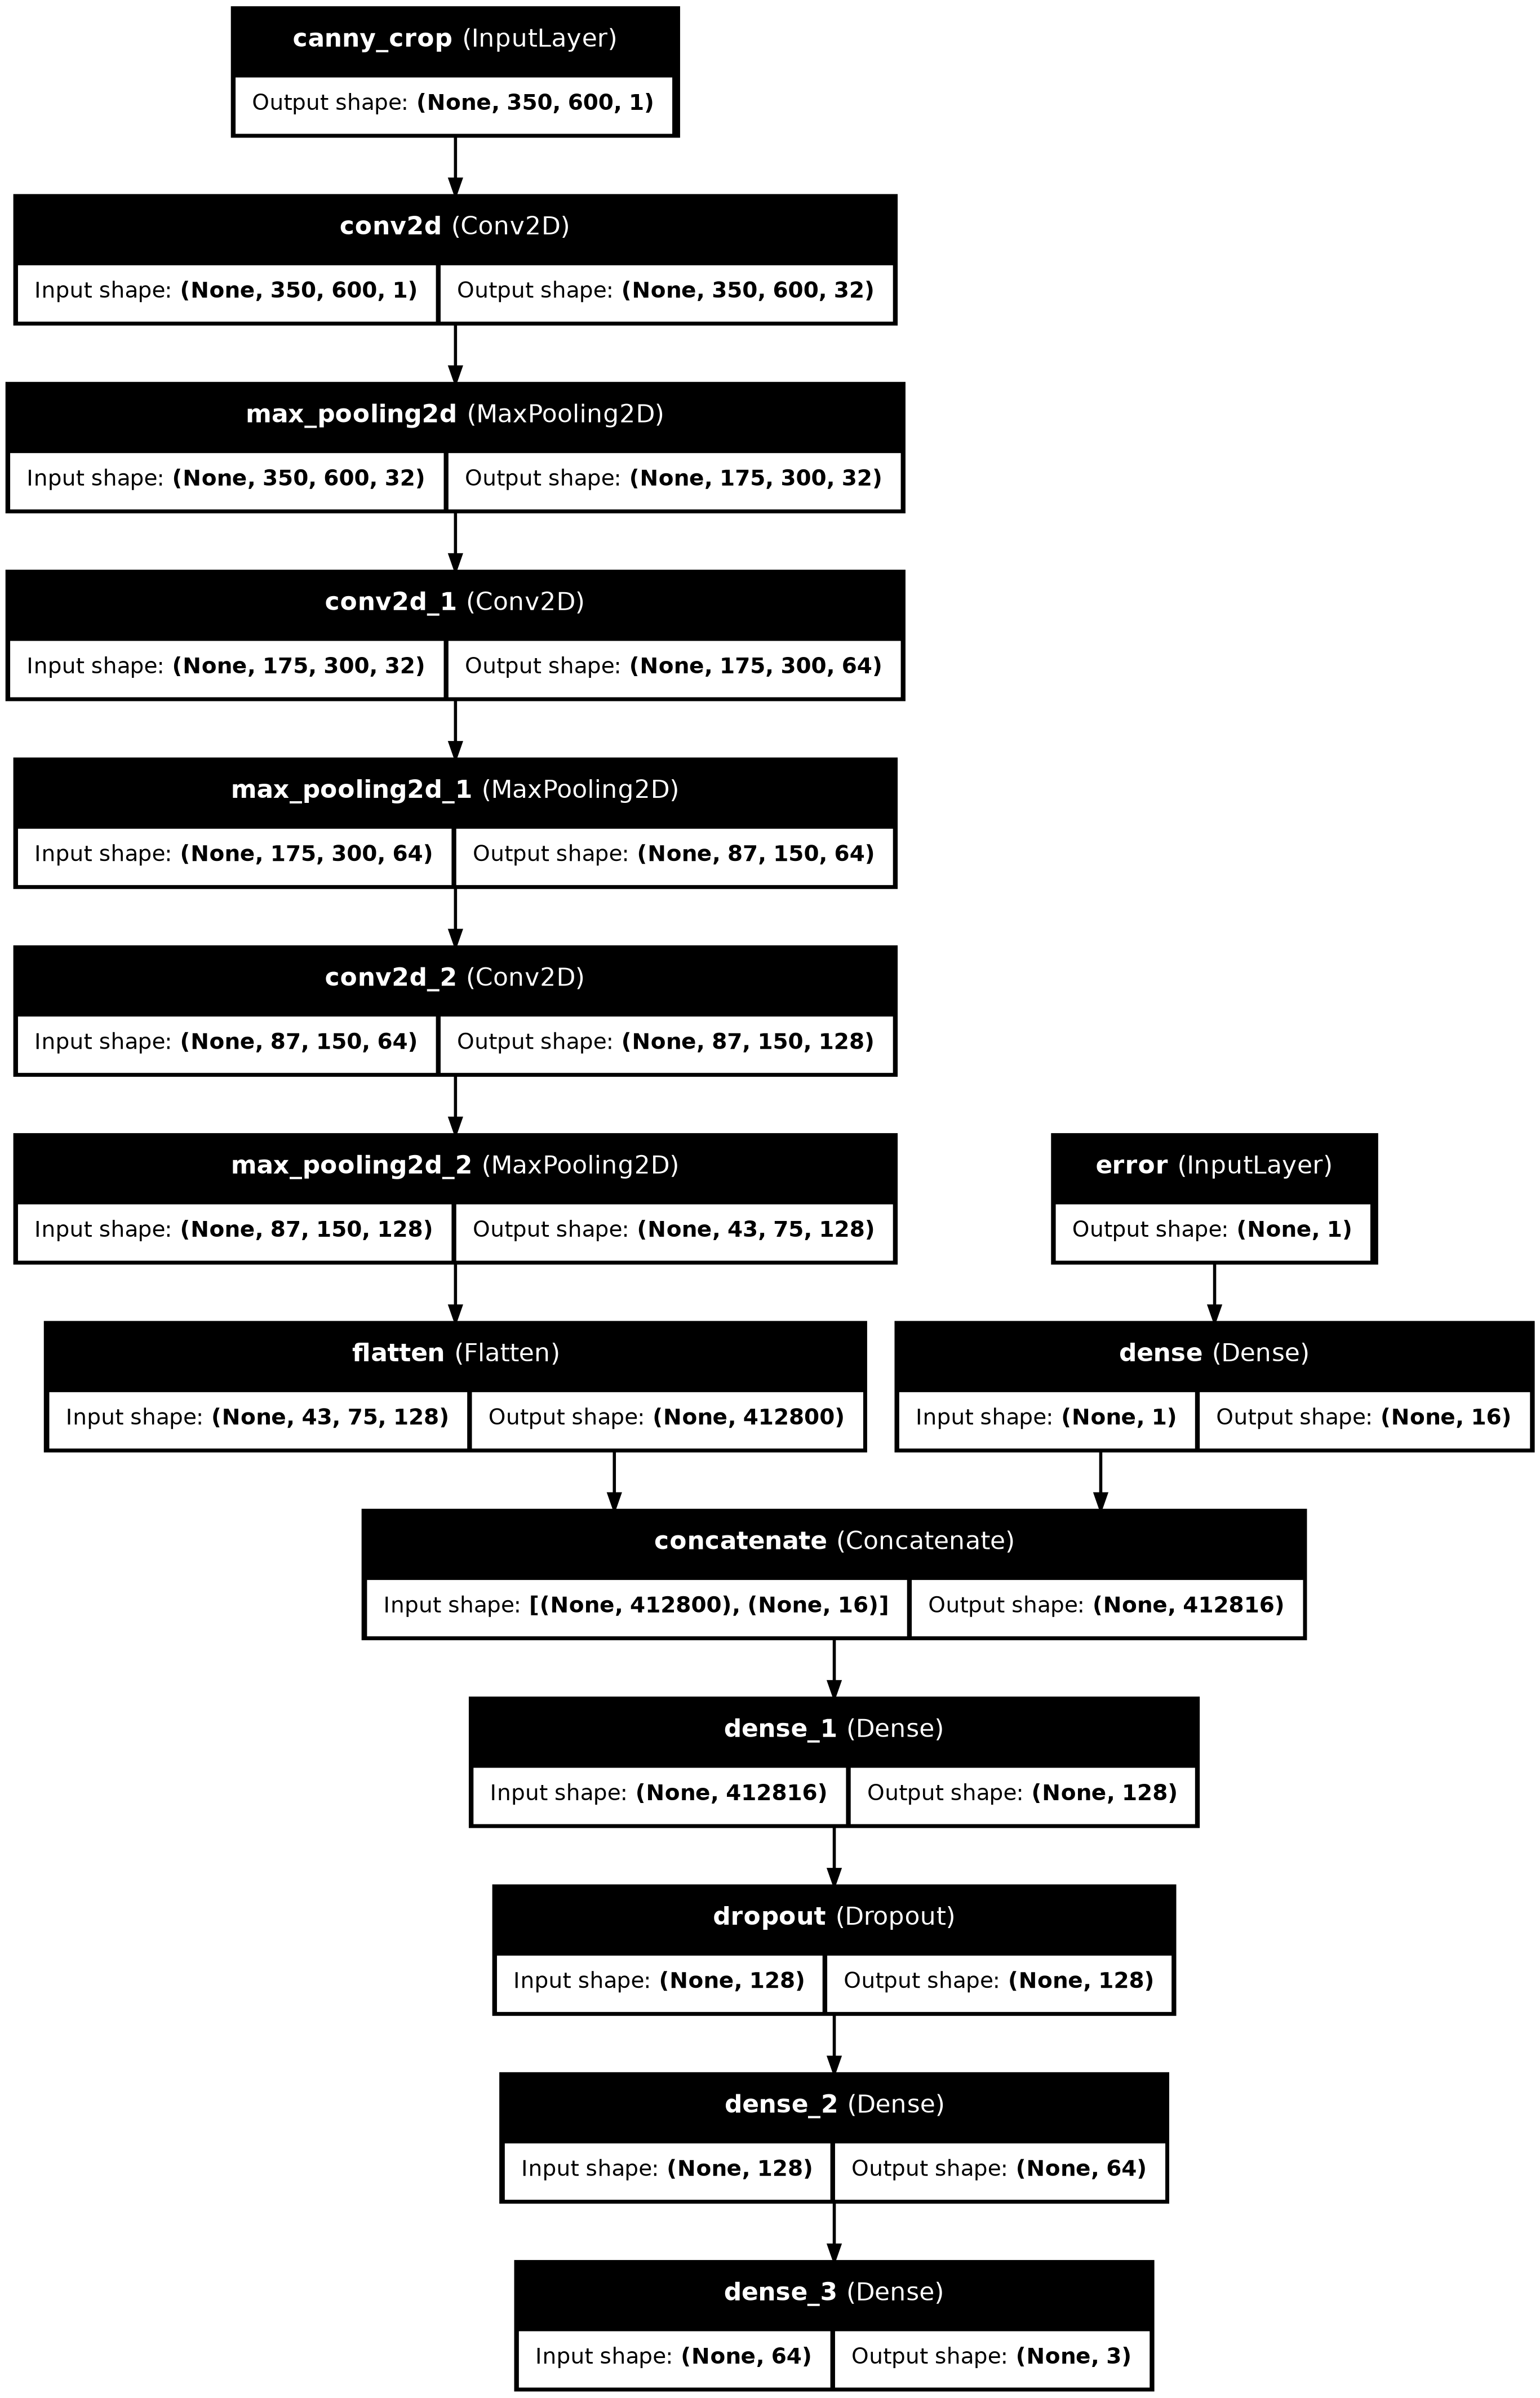

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file=f'images/{model_name}_model_plot_{timestamp}.png', show_shapes=True, show_layer_names=True)


In [3]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ canny_crop          │ (None, 5, 200, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 5, 200,    │        160 │ canny_crop[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 2, 100,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 2, 100,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 1, 50, 32) │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ error (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1600)      │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │         16 │ error[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1608)      │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │     51,488 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 3)         │         99 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 56,403 (220.32 KB)

 Trainable params: 56,403 (220.32 KB)

 Non-trainable params: 0 (0.00 B)

|                  | Layer 1    | Layer 2  | Layer 3     | Layer 4  | Layer 5     | Layer 6 | Layer 7 | Layer 8 | Layer 9  | Layer 10 | Layer 11 |
|------------------|------------|----------|-------------|----------|-------------|---------|------|------|----------|-------|-------|
| **Type**         | InputLayer | Conv2D   | MaxPooling2D| Conv2D   | MaxPooling2D| InputLayer | Flatten | Dense | Concatenate | Dense | Dense |
| **Output Shape** | (5, 200, 1) | (5, 200, 16) | (2, 100, 16) | (2, 100, 32) | (1, 50, 32) | 1 | 1600 | 8 | 1608 | 32 | 3 |
| **Parameters**   | 0          | 160      | 0           | 4,640    | 0           | 0       | 0    | 16   | 0        | 51,488 | 99    |
